# Static discrete choice — code from the lecture

Every code example from the *Programming practice: static discrete choice* chapter of
the lecture notes, in the order it appears there: <https://dse.iskh.me/logit>

Run the cells top to bottom — later ones use names defined earlier.

## Extreme value distribution and max-stability

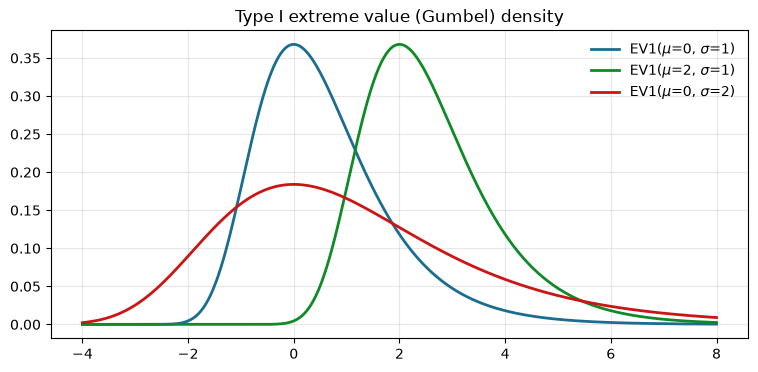

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [9, 4]

x = np.linspace(-4, 8, 500)
ev1_pdf = lambda x, mu=0., s=1.: np.exp(-(x-mu)/s - np.exp(-(x-mu)/s))/s
fig, ax = plt.subplots()
for mu, s, c in [(0., 1., '#1A6D91'), (2., 1., '#0E8A27'), (0., 2., '#CB1515')]:
    ax.plot(x, ev1_pdf(x, mu, s), lw=2, color=c, label=f'EV1($\\mu$={mu:g}, $\\sigma$={s:g})')
ax.legend(frameon=False)
ax.set_title('Type I extreme value (Gumbel) density')
ax.grid(True, alpha=.3)
plt.show()

In [2]:
rng = np.random.default_rng(42)
mu, sigma, n = np.array([0., 1., 2.5]), 1.5, 500_000
draws = mu + sigma * rng.gumbel(size=(n, mu.size))   # EV1(mu_i, sigma), independent
mx = draws.max(axis=1)                               # the maximum over alternatives
mu_max = sigma * np.log(np.sum(np.exp(mu/sigma)))    # logsum formula
print(f'simulated mean of the max = {mx.mean():.4f}')
print(f'logsum + sigma*gamma      = {mu_max + sigma*np.euler_gamma:.4f}')
print(f'simulated variance        = {mx.var():.4f}   theory = {sigma**2*np.pi**2/6:.4f}')

simulated mean of the max = 4.0276
logsum + sigma*gamma      = 4.0297
simulated variance        = 3.6895   theory = 3.7011


## Exponentiation is dangerous

In [3]:
a = 2.
for i in range(14):
    print(f'i={i:2d}   a={a:.3e}   exp(a)={np.exp(a):.3e}')
    a **= 1.25

i= 0   a=2.000e+00   exp(a)=7.389e+00
i= 1   a=2.378e+00   exp(a)=1.079e+01
i= 2   a=2.954e+00   exp(a)=1.918e+01
i= 3   a=3.872e+00   exp(a)=4.804e+01
i= 4   a=5.432e+00   exp(a)=2.285e+02
i= 5   a=8.292e+00   exp(a)=3.993e+03
i= 6   a=1.407e+01   exp(a)=1.292e+06
i= 7   a=2.725e+01   exp(a)=6.856e+11
i= 8   a=6.227e+01   exp(a)=1.105e+27
i= 9   a=1.749e+02   exp(a)=9.297e+75
i=10   a=6.362e+02   exp(a)=1.892e+276
i=11   a=3.195e+03   exp(a)=inf
i=12   a=2.402e+04   exp(a)=inf
i=13   a=2.990e+05   exp(a)=inf


/var/folders/3l/41z_6pkn36q_r9d6dl_4fstr0000gp/T/ipykernel_31509/1817667625.py:3: RuntimeWarning: overflow encountered in exp
  print(f'i={i:2d}   a={a:.3e}   exp(a)={np.exp(a):.3e}')


In [4]:
print(f'largest double      = {np.finfo(float).max:.6e}')
print(f'log of it           = {np.log(np.finfo(float).max):.6f}')
print(f'smallest normal     = {np.finfo(float).tiny:.6e}')
print(f'log of it           = {np.log(np.finfo(float).tiny):.6f}')

largest double      = 1.797693e+308
log of it           = 709.782713
smallest normal     = 2.225074e-308
log of it           = -708.396419


In [5]:
def logit_naive(v, sigma=1.0, axis=0):
    '''Logit choice probabilities, straight from the formula'''
    e = np.exp(np.asarray(v)/sigma)
    return e/e.sum(axis=axis, keepdims=True)

v = np.array([1000., 1001., 999.])       # utility differences are just 1 and 2
with np.errstate(over='ignore', invalid='ignore'):
    print('naive :', logit_naive(v))

naive : [nan nan nan]


## De-maxing

In [6]:
def logit(v, sigma=1.0, axis=0):
    '''Logit choice probabilities, computed with de-maxing.
    Alternatives along the given axis, any other dimensions are states.
    '''
    v = np.asarray(v, dtype=float)/sigma
    mx = np.max(v, axis=axis, keepdims=True)      # de-maxing constant
    e = np.exp(v - mx)                            # exponent of non-positive numbers
    return e/e.sum(axis=axis, keepdims=True)

def logsum(v, sigma=1.0, axis=0):
    '''Log-sum-exp = expected maximum of v + EV1 shocks, up to sigma*gamma'''
    v = np.asarray(v, dtype=float)/sigma
    mx = np.max(v, axis=axis, keepdims=True)
    ls = mx + np.log(np.sum(np.exp(v - mx), axis=axis, keepdims=True))
    return sigma*np.squeeze(ls, axis=axis)

print('de-maxed :', logit(v))
print('logsum   :', logsum(v), ' vs naive:', np.log(np.sum(np.exp(v))))

de-maxed : [0.24472847 0.66524096 0.09003057]
logsum   : 1001.4076059644444  vs naive: inf


/var/folders/3l/41z_6pkn36q_r9d6dl_4fstr0000gp/T/ipykernel_31509/3362587460.py:18: RuntimeWarning: overflow encountered in exp
  print('logsum   :', logsum(v), ' vs naive:', np.log(np.sum(np.exp(v))))


## Never take the log of a probability

In [7]:
def loglogit(v, sigma=1.0, axis=0):
    '''Log of the logit choice probabilities, without ever taking log of a probability'''
    v = np.asarray(v, dtype=float)
    return (v - np.expand_dims(logsum(v, sigma, axis), axis))/sigma

w = np.array([0., -40., -900.])            # third alternative is hopeless
with np.errstate(divide='ignore'):
    print('log(logit(w)) :', np.log(logit(w)))
print('loglogit(w)   :', loglogit(w))

log(logit(w)) : [  0. -40. -inf]
loglogit(w)   : [   0.  -40. -900.]


## The scale parameter is a numerical hazard

In [8]:
u = np.array([1.0, 1.5, 0.8])
for s in [10., 1., 0.1, 1e-3, 1e-8]:
    with np.errstate(over='ignore', invalid='ignore'):
        naive = logit_naive(u, sigma=s)
    print(f'sigma={s:<8g} naive={np.array2string(naive, precision=3)}'
          f'   de-maxed={np.array2string(logit(u, sigma=s), precision=3)}')

sigma=10       naive=[0.33  0.347 0.323]   de-maxed=[0.33  0.347 0.323]
sigma=1        naive=[0.288 0.475 0.236]   de-maxed=[0.288 0.475 0.236]
sigma=0.1      naive=[6.687e-03 9.924e-01 9.050e-04]   de-maxed=[6.687e-03 9.924e-01 9.050e-04]
sigma=0.001    naive=[nan nan nan]   de-maxed=[7.125e-218 1.000e+000 9.860e-305]
sigma=1e-08    naive=[nan nan nan]   de-maxed=[0. 1. 0.]


In [9]:
p = logit(np.array([[1., 2.], [3., 0.], [-2., 5.]]), sigma=0.4)   # 3 alternatives x 2 states
print(p, end='\n\n')
assert np.allclose(p.sum(axis=0), 1.0), 'choice probabilities must sum to one'
assert np.all(p >= 0.), 'choice probabilities must be non-negative'
print('sums over alternatives:', p.sum(axis=0))

[[6.69282615e-03 5.52776578e-04]
 [9.93303472e-01 3.72457929e-06]
 [3.70169754e-06 9.99443499e-01]]

sums over alternatives: [1. 1.]


## Logit as a smoothing device

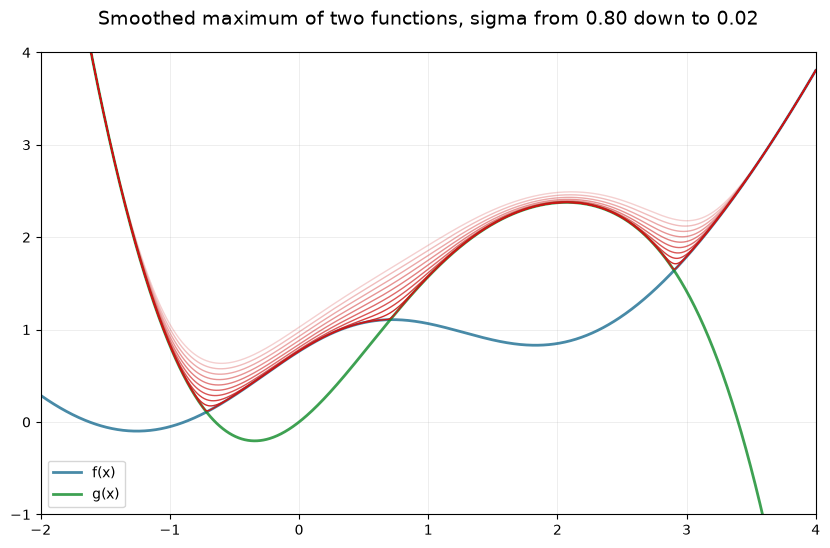

In [10]:
x = np.linspace(-2, 4, 1000)
f1 = 2 * np.exp(-0.5 * (x - 0.5)**2) + 0.3 * x**2 - 1
f2 = -0.4 * x**3 + 1.2 * x**2 + 0.5 * x + 0.5 + 0.3 * np.sin(2*x) - 0.5
f3 = lambda s: s * np.log(np.exp(f1/s) + np.exp(f2/s))
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.plot(x, f1, linewidth=2.0, color="#1A6D91", label='f(x)', alpha=0.8)
ax.plot(x, f2, linewidth=2.0, color="#0E8A27", label='g(x)', alpha=0.8)
ax.legend(frameon=True, loc='lower left')
s1, s2 = 0.02, 0.8
for s in np.linspace(s1, s2, 10):
    ax.plot(x, f3(s), linewidth=1.0, color="#CB1515", alpha=1 - s)
ax.set_title(f'Smoothed maximum of two functions, sigma from {s2:0.2f} down to {s1:0.2f}', fontsize=14, pad=20)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim(-2, 4); ax.set_ylim(-1, 4)
plt.show()

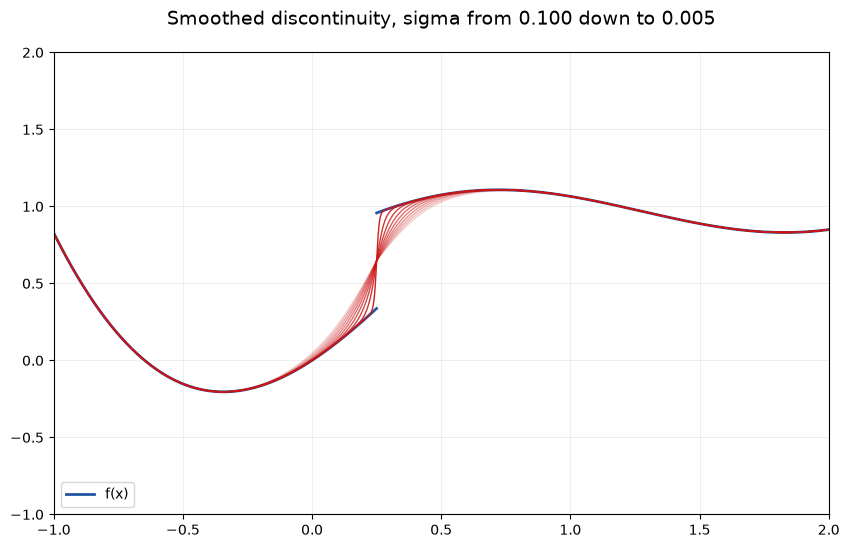

In [11]:
x0 = 0.25
x = np.linspace(-1, 2, 10000)
g1 = lambda x: -0.4 * x**3 + 1.2 * x**2 + 0.5 * x + 0.5 + 0.3 * np.sin(2*x) - 0.5
g2 = lambda x: 2 * np.exp(-0.5 * (x - 0.5)**2) + 0.3 * x**2 - 1
fd = (x < x0)*g1(x) + (x > x0)*g2(x)
ix = np.max(np.where(x <= x0))
gap = g2(x[ix]) - g1(x[ix])
fd[ix] = np.nan                                   # to show the discontinuity
smooth = lambda x, s: fd + gap*(1/(1 + np.exp(-(x - x0)/s)) - (x > x0))
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.plot(x, fd, linewidth=2.0, color="#2355A1", label='f(x)')
ax.legend(frameon=True, loc='lower left')
s1, s2 = 0.005, 0.1
for s in np.linspace(s1, s2, 10):
    ax.plot(x, smooth(x, s), linewidth=1.0, color="#CB1515", alpha=1 - 8*s)
ax.set_title(f'Smoothed discontinuity, sigma from {s2:0.3f} down to {s1:0.3f}', fontsize=14, pad=20)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim(-1, 2); ax.set_ylim(-1, 2)
plt.show()

## The model object

In [12]:
class model:
    '''Static random utility model with EV1 taste shocks'''

    def __init__(self,
                 label='noname',
                 nalt=5,                    # number of alternatives
                 nattr=3,                   # number of attributes of each alternative
                 attr=None,                 # attribute values Y, (nalt, nattr)
                 param=None,                # structural parameters beta, (nattr,)
                 st=np.array([1, 2]),       # states of the decision maker
                 util_type='linear',        # 'linear' or 'log'
                 sigma=1.0):                # scale of the taste shocks
        self.label = label
        self.nalt = nalt                    # dimensions first: __setattr__ checks against them
        self.nattr = nattr
        self.st = st
        self.util_type = util_type
        self.sigma = sigma
        self.attr = np.ones((nalt, nattr)) if attr is None else attr
        self.param = np.zeros(nattr) if param is None else param

    def __str__(self):
        '''Human readable representation of the model'''
        return (f'Model "{self.label}" [{self.util_type}]: {self.nalt} alternatives, '
                f'{self.nattr} attributes, {self.st.size} states, sigma={self.sigma:g}\n'
                f'  beta = {np.array2string(self.param, precision=3, separator=", ")}')

    def __setattr__(self, name, value):
        '''Check consistency of the model attributes on assignment'''
        if name == 'attr':
            value = np.asarray(value, dtype=float)
            assert value.shape == (self.nalt, self.nattr), \
                f'attr must have shape ({self.nalt}, {self.nattr}), got {value.shape}'
        if name == 'param':
            value = np.asarray(value, dtype=float)
            assert value.size == self.nattr, \
                f'param must have {self.nattr} elements, got {value.size}'
        if name == 'sigma':
            assert value > 0, 'sigma must be strictly positive'
        super().__setattr__(name, value)

    # ---- model parts ----

    def beta_coef(self):
        '''State-specific coefficients, (nattr, nstates)'''
        beta_st = np.empty((self.nattr, self.st.size))
        beta_st[:, 0] = self.param
        beta_st[:, 1] = self.param/2
        return beta_st

    def utility(self):
        '''Deterministic component of utility, (nalt, nstates)'''
        if self.util_type == 'linear':
            return self.attr @ self.beta_coef()
        elif self.util_type == 'log':
            return np.log(self.attr) @ self.beta_coef()
        raise ValueError(f'Unknown utility specification: {self.util_type}')

    def save_solution(self, chpr):
        '''Store the computed choice probabilities in the model object'''
        self.solution = chpr

## The solver

In [13]:
def model_solve(m):
    '''Solve the model: choice probabilities, alternatives in rows, states in columns'''
    chpr = logit(m.utility(), sigma=m.sigma, axis=0)     # de-maxed, see above
    assert np.allclose(chpr.sum(axis=0), 1.0), 'choice probabilities do not sum to one'
    m.save_solution(chpr)
    return chpr

def model_logsolve(m):
    '''Log choice probabilities, for the likelihood later in the course'''
    return loglogit(m.utility(), sigma=m.sigma, axis=0)

## The simulator

In [14]:
import pandas as pd

def model_simulate(m, chpr=None, nobs=10, rng=None):
    '''Simulate nobs decision makers from a solved model, return a pandas DataFrame'''
    assert chpr is not None or hasattr(m, 'solution'), \
        'solve the model first, or pass choice probabilities to the simulator'
    chpr = m.solution if chpr is None else chpr
    rng = np.random.default_rng() if rng is None else rng
    var_names = ['id', 'st', 'choice'] + [f'attr{i}' for i in range(1, m.nattr + 1)]
    data = pd.DataFrame(np.nan, index=range(nobs), columns=var_names)
    data['id'] = 1 + np.arange(nobs)
    data['st'] = rng.integers(m.st.size, size=nobs)          # states drawn uniformly
    cumulative = np.cumsum(chpr, axis=0)                     # cdf over alternatives
    u = rng.random(nobs)                                     # uniform draws
    for st in range(m.st.size):
        mask = data['st'] == st
        # inverse cdf: index of the first cumulative probability exceeding u
        data.loc[mask, 'choice'] = np.searchsorted(cumulative[:, st], u[mask], side='right')
        # attach the attributes of the chosen alternative
        data.loc[mask, var_names[3:]] = m.attr[data.loc[mask, 'choice'].astype(int), :]
    dtypes = [np.int32, np.int32, np.int32] + [np.float64]*m.nattr
    return data.astype(dict(zip(var_names, dtypes)))

In [15]:
rng = np.random.default_rng(2026)
nalt, nattr = 5, 3
attr = rng.uniform(1, 10, size=(nalt, nattr))
m1 = model(nalt=nalt, nattr=nattr, attr=attr, param=np.array([0.1, 0.35, 0.2]), label='model 1')
print(m1)
model_solve(m1)
simdata = model_simulate(m1, nobs=2500, rng=rng)
simdata.head()

Model "model 1" [linear]: 5 alternatives, 3 attributes, 2 states, sigma=1
  beta = [0.1 , 0.35, 0.2 ]


,id,st,choice,attr1,attr2,attr3
0,1,1,2,9.146295,2.596179,6.875063
1,2,1,4,6.722837,7.774589,5.636383
2,3,1,3,3.684725,9.702660,9.278651
3,4,0,4,6.722837,7.774589,5.636383
4,5,0,3,3.684725,9.702660,9.278651


## The graphical module

In [16]:
import matplotlib

def plot_attributes(m, ax=None):
    '''Bar plot of the attributes of each alternative'''
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    width, x = 0.25, np.arange(m.nalt)
    for i in range(m.nattr):
        ax.bar(x + width*i, m.attr[:, i], width, label=f'attr{i+1}')
    ax.set_ylim(0, ax.get_ylim()[1]*1.15)
    ax.set_title(f'Attributes — {m.label}', fontsize=12)
    ax.set_xlabel('Alternatives')
    ax.legend(loc='upper left', ncols=m.nattr, fontsize=8)

def plot_choice_probabilities(m, ax=None):
    '''Bar plot of the model solution, one panel per state'''
    assert hasattr(m, 'solution'), 'solve the model before plotting its solution'
    if ax is None:
        fig, ax = plt.subplots(1, m.st.size, figsize=(10, 4))
        fig.suptitle(f'Choice probabilities — {m.label}', fontsize=13)
    ymax = 0
    for i in range(min(len(ax), m.st.size)):
        ax[i].bar(range(m.nalt), m.solution[:, i], color='xkcd:fresh green')
        ax[i].set_title(f'State {i}', fontsize=11)
        ax[i].set_xlabel('Alternatives')
        ax[i].set_ylabel('Probability')
        ymax = max(ymax, ax[i].get_ylim()[1])
    for i in range(min(len(ax), m.st.size)):
        ax[i].set_ylim(0, ymax)          # common vertical scale, or the panels lie

def plot_data(m, data, ax=None):
    '''Histograms of simulated choices: pooled, then one panel per state'''
    if ax is None:
        fig, ax = plt.subplots(1, m.st.size + 1, figsize=(12, 4))
        fig.suptitle(f'Frequencies of simulated choices — {m.label}', fontsize=13)
    bins = np.arange(-.5, m.nalt + .5, 1)
    nax, ymax = min(len(ax), m.st.size + 1), 0
    for i in range(nax):
        if i == 0:
            ax[i].hist(data['choice'], bins=bins, edgecolor='white', color='xkcd:light blue')
            ax[i].set_title(f'Pooled, obs={data.shape[0]}', fontsize=11)
        else:
            mask = data['st'] == i - 1
            ax[i].hist(data.loc[mask, 'choice'], bins=bins, edgecolor='white', color='xkcd:pale orange')
            ax[i].set_title(f'State {i-1}, obs={mask.sum()}', fontsize=11)
        ax[i].set_xlabel('Alternatives')
        ax[i].set_ylabel('Frequency')
        ymax = max(ymax, ax[i].get_ylim()[1])
    for i in range(nax):
        ax[i].set_ylim(0, ymax)

def plot_dashboard(m, data):
    '''Attributes and solution on top, simulated data below'''
    ncols = m.st.size + 1
    fig, axs = plt.subplots(2, ncols, figsize=(12, 7), layout='constrained')
    fig.suptitle(f'Dashboard — {m.label}', fontsize=14)
    ax = list(axs.flatten())
    plot_attributes(m, ax=ax[0])
    plot_choice_probabilities(m, ax=ax[1:ncols])
    plot_data(m, data=data, ax=ax[ncols:2*ncols])

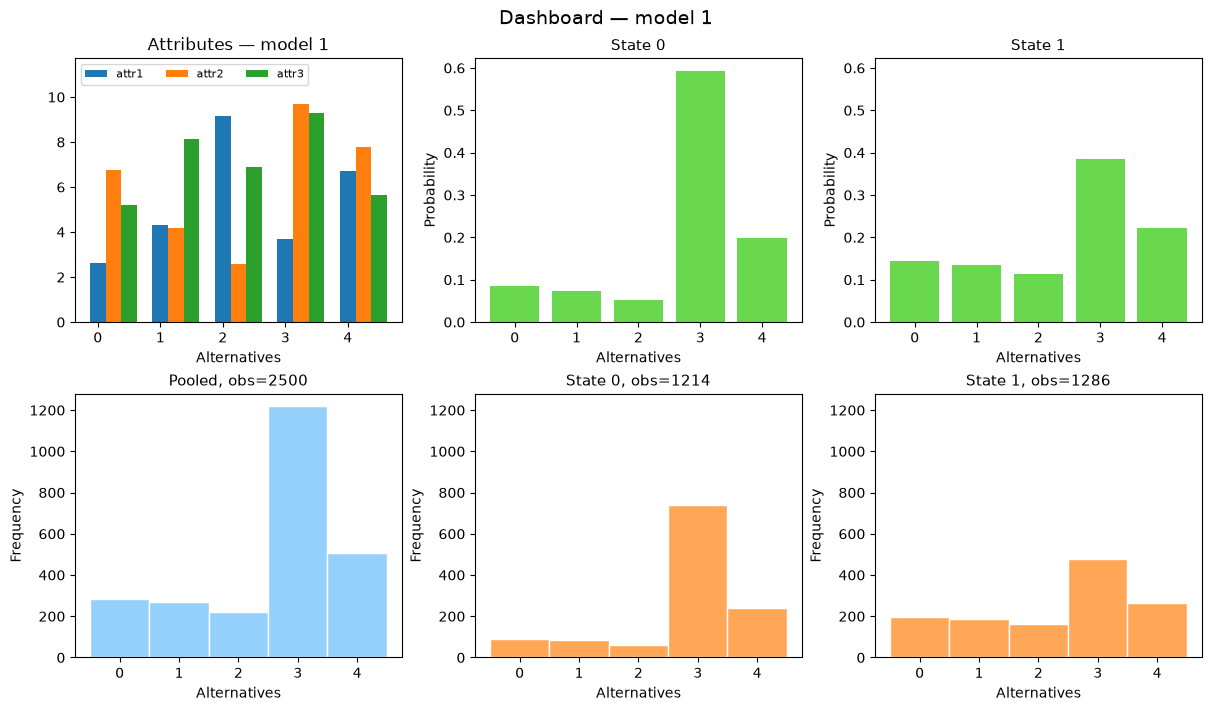

In [17]:
plot_dashboard(m1, data=simdata)
plt.show()

## Playing with the model

In [18]:
def compare(models, data=None):
    '''Solve several models and put their choice probabilities side by side'''
    fig, axs = plt.subplots(len(models), 2, figsize=(10, 3.2*len(models)), layout='constrained')
    axs = np.atleast_2d(axs)
    for k, m in enumerate(models):
        model_solve(m)
        plot_choice_probabilities(m, ax=list(axs[k]))
        axs[k][0].set_ylabel(f'{m.label}\nProbability')
    plt.show()

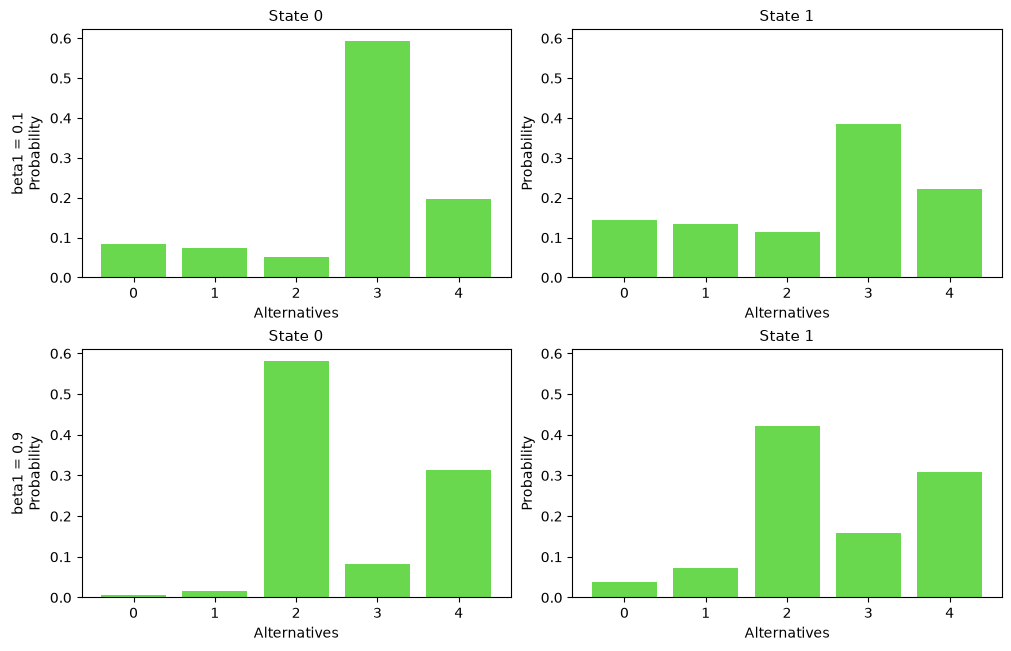

In [19]:
mA = model(nalt=nalt, nattr=nattr, attr=attr, param=np.array([0.1, 0.35, 0.2]), label='beta1 = 0.1')
mB = model(nalt=nalt, nattr=nattr, attr=attr, param=np.array([0.9, 0.35, 0.2]), label='beta1 = 0.9')
compare([mA, mB])

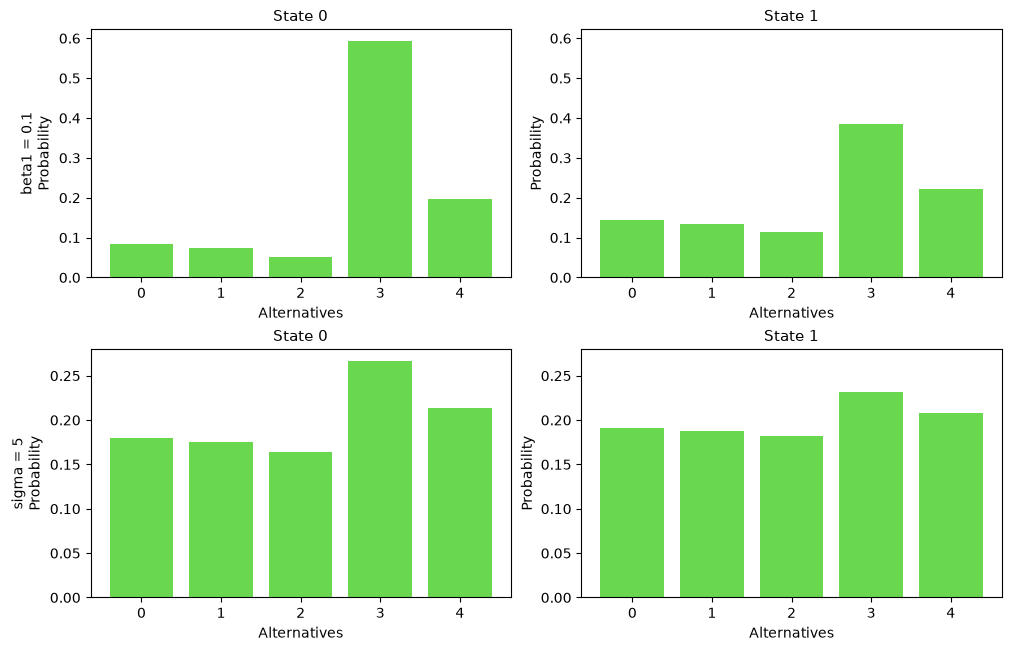

In [20]:
mC = model(nalt=nalt, nattr=nattr, attr=attr, param=mA.param, sigma=5.0, label='sigma = 5')
compare([mA, mC])

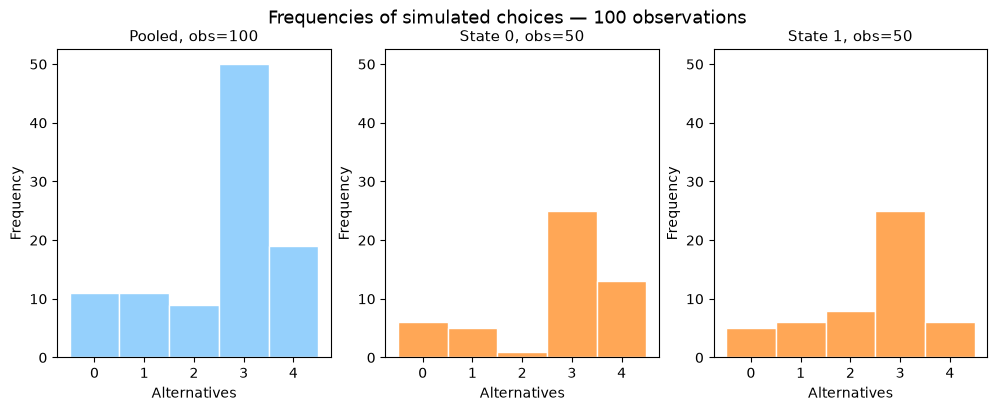

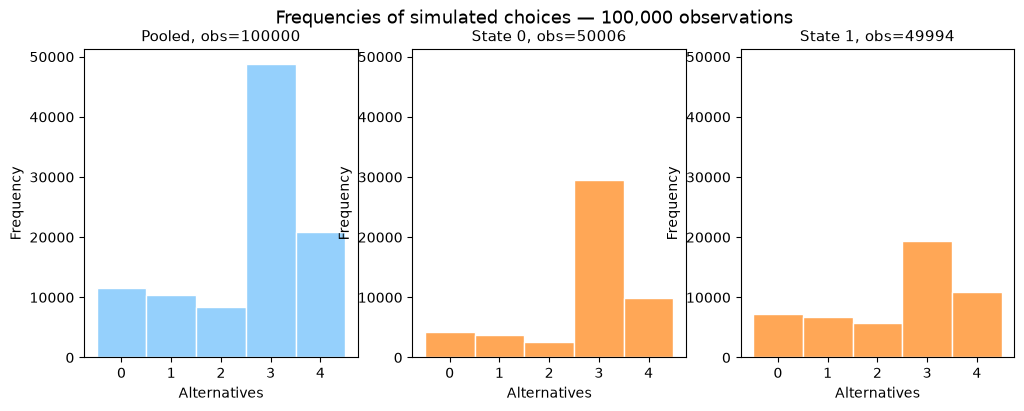

In [21]:
model_solve(mA)
small = model_simulate(mA, nobs=100, rng=rng)
large = model_simulate(mA, nobs=100_000, rng=rng)
for d, ttl in [(small, '100 observations'), (large, '100,000 observations')]:
    mA.label = ttl
    plot_data(mA, data=d)
    plt.show()
mA.label = 'beta1 = 0.1'

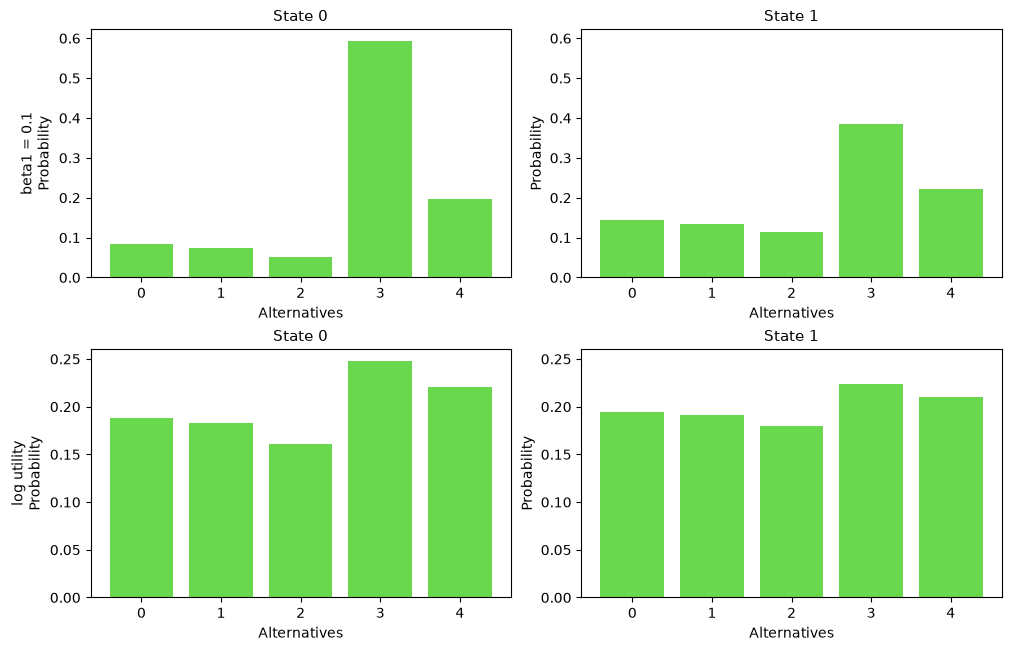

In [22]:
mF = model(nalt=nalt, nattr=nattr, attr=attr, param=mA.param, util_type='log', label='log utility')
compare([mA, mF])